# Исследование рынка российского кинопроката

Данное исследование ставить перед собой целью изучить рынок российского кинопроката и выявить текущие тренды. Также я постараюсь ответить на вопрос, насколько фильмы, которые получили государственную поддержку, интересны зрителю.

## План работы

1. Изучение общей информации о данных
2. Предобработка данных
3. Добавление новых столбцов
4. Исследовательский анализ данных
5. Общий вывод

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
mkrf_shows = pd.read_csv("./mkrf_shows.csv")
mkrf_movies = pd.read_csv("./mkrf_movies.csv")

In [11]:
avg_ceiling_height = math.ceil(df['ceiling_height'].mean() * 100) / 100
df['ceiling_height'] = df['ceiling_height'].fillna(avg_ceiling_height)
display(df['ceiling_height'].isna().sum())

0

##### Заполнение пропусков в общем количестве этажей

In [12]:
df[df['floors_total'].isna()]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
186,12,11640000.0,65.2,2018-10-02T00:00:00,2,2.78,NaN,30.80,4,NaN,...,12.00,NaN,Санкт-Петербург,39197.0,12373.0,1.0,123.0,0.0,NaN,49.0
237,4,2438033.0,28.1,2016-11-23T00:00:00,1,2.78,NaN,20.75,1,NaN,...,NaN,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,251.0
457,4,9788348.0,70.8,2015-08-01T00:00:00,2,2.78,NaN,38.40,12,NaN,...,10.63,0.0,Санкт-Петербург,37364.0,8322.0,2.0,309.0,2.0,706.0,727.0
671,4,6051191.0,93.6,2017-04-06T00:00:00,3,2.78,NaN,47.10,8,NaN,...,16.80,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,123.0
1757,5,3600000.0,39.0,2017-04-22T00:00:00,1,2.78,NaN,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,22735.0,11618.0,1.0,835.0,1.0,652.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22542,5,8500000.0,63.5,2017-05-24T00:00:00,2,2.80,NaN,NaN,3,NaN,...,NaN,NaN,Санкт-Петербург,51340.0,15363.0,0.0,NaN,1.0,853.0,512.0
22656,4,4574160.0,64.5,2017-04-02T00:00:00,2,2.78,NaN,31.70,20,NaN,...,14.40,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,127.0
22808,0,14569263.0,110.4,2016-11-20T00:00:00,3,2.78,NaN,45.38,6,NaN,...,23.42,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,260.0
23590,0,21187872.0,123.3,2017-04-25T00:00:00,3,2.78,NaN,50.40,18,NaN,...,23.60,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,104.0


Можно заметить что все квартиры, у которых `floors_total` имеет значение NaN. Такие целосообразней удалить

In [13]:
df = df.dropna(subset=['floors_total'])
df['floors_total'].isna().sum()

0

##### Заполнение пропусков в столбце `is_apartment`

In [14]:
df[df['is_apartment'].isna() & df['total_area'] < 200]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.78,11.0,18.6,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.78,5.0,34.3,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,2.78,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,2.78,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,2.78,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


##### Заполнение пропусков в жилой площади

In [15]:
df[df['living_area'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.78,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
7,5,7915000.0,71.6,2019-04-18T00:00:00,2,2.78,24.0,NaN,22,NaN,...,18.9,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
30,12,2200000.0,32.8,2018-02-19T00:00:00,1,2.78,9.0,NaN,2,NaN,...,NaN,NaN,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.8,2017-10-28T00:00:00,2,2.50,5.0,NaN,1,NaN,...,NaN,NaN,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,NaN,3,NaN,...,NaN,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
59,15,6300000.0,46.5,2017-03-06T00:00:00,1,2.78,13.0,NaN,13,NaN,...,NaN,NaN,Санкт-Петербург,11125.0,14501.0,0.0,NaN,0.0,NaN,336.0
60,3,2740000.0,35.0,2018-01-01T00:00:00,1,2.78,12.0,NaN,8,NaN,...,NaN,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
81,9,10949000.0,68.0,2018-12-27T00:00:00,1,2.78,10.0,NaN,6,NaN,...,NaN,NaN,Санкт-Петербург,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,3,4500000.0,80.5,2018-01-15T00:00:00,3,2.78,25.0,NaN,16,NaN,...,NaN,NaN,посёлок Шушары,12430.0,18217.0,0.0,NaN,0.0,NaN,60.0
116,18,10999000.0,97.2,2017-11-13T00:00:00,3,2.50,16.0,NaN,16,NaN,...,18.3,5.0,Санкт-Петербург,19426.0,21138.0,0.0,NaN,2.0,390.0,394.0


Пропущенная площадь не имеет никакой закономерности. Скорее всего это банальная ошибка в сборе данных, пропуски следует заменить на средние значения по всему датасету

In [16]:
avg_living_area = math.ceil(df['living_area'].mean() * 100) / 100
df['living_area'] = df['living_area'].fillna(avg_living_area)
display(df['living_area'].isna().sum())

0

##### Заполнение пропусков в колонке балконов

In [17]:
df[df['balcony'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.78,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.78,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
10,5,5050000.0,39.60,2017-11-16T00:00:00,1,2.67,12.0,20.30,3,NaN,...,8.50,NaN,Санкт-Петербург,38357.0,13878.0,1.0,310.0,2.0,553.0,137.0
16,11,6700000.0,82.00,2017-11-23T00:00:00,3,3.05,5.0,55.60,1,NaN,...,9.00,NaN,Санкт-Петербург,22108.0,10698.0,3.0,420.0,0.0,NaN,397.0
19,16,14200000.0,121.00,2019-01-09T00:00:00,3,2.75,16.0,76.00,8,NaN,...,12.00,NaN,Санкт-Петербург,38900.0,12843.0,0.0,NaN,0.0,NaN,97.0
23,11,2950000.0,32.00,2016-10-29T00:00:00,1,2.60,9.0,17.70,9,NaN,...,6.10,NaN,Санкт-Петербург,15414.0,14211.0,2.0,517.0,1.0,190.0,615.0
26,6,4050000.0,60.00,2017-04-28T00:00:00,4,2.78,5.0,43.00,4,NaN,...,7.00,NaN,Санкт-Петербург,11580.0,10510.0,0.0,NaN,1.0,95.0,265.0
30,12,2200000.0,32.80,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,NaN,NaN,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0


 Скорее всего балконы являлись опциональным полем ввода и не все люди ввели данные о своих балконах, т.к. посчитали это бесмысленным из-за их отсутствия. Целесообразно заменить эти значения на 0

In [18]:
df['balcony'] = df['balcony'].fillna(0)
df['balcony'].isna().sum()

0

##### Заполнение пропусков в колонке площади кухни

In [19]:
df[df['kitchen_area'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,2.78,14.0,34.47,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
30,12,2200000.0,32.8,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,NaN,0.0,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.8,2017-10-28T00:00:00,2,2.50,5.0,34.47,1,NaN,...,NaN,0.0,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,34.47,3,NaN,...,NaN,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
59,15,6300000.0,46.5,2017-03-06T00:00:00,1,2.78,13.0,34.47,13,NaN,...,NaN,0.0,Санкт-Петербург,11125.0,14501.0,0.0,NaN,0.0,NaN,336.0
60,3,2740000.0,35.0,2018-01-01T00:00:00,1,2.78,12.0,34.47,8,NaN,...,NaN,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
81,9,10949000.0,68.0,2018-12-27T00:00:00,1,2.78,10.0,34.47,6,NaN,...,NaN,0.0,Санкт-Петербург,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,3,4500000.0,80.5,2018-01-15T00:00:00,3,2.78,25.0,34.47,16,NaN,...,NaN,0.0,посёлок Шушары,12430.0,18217.0,0.0,NaN,0.0,NaN,60.0
133,12,3150000.0,31.0,2018-03-23T00:00:00,1,2.78,25.0,34.47,6,NaN,...,NaN,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,78.0
144,1,2450000.0,27.0,2017-03-30T00:00:00,0,2.78,24.0,15.50,2,NaN,...,NaN,2.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,181.0


Скорее всего площадь кухни была пропущенна из-за того что, либо кухня в квартире отсутствует (это объявление на коммунальную квартиру) либо это часть данных не была собрана по какой-то технической причине. Пропущенные значение можно заменить на среднюю площадь кухни

In [20]:
avg_kitchen_area = math.ceil(df['kitchen_area'].mean() * 10) / 10
df['kitchen_area'] = df['kitchen_area'].fillna(avg_kitchen_area)
display(df['kitchen_area'].isna().sum())

0

После заполнения площадей кухни необходимо проверить что столбец общей площади сходится с площадью кухни + жилой площадью

In [21]:
def kitchen_area_check(row):
    real_total_area = row['total_area']
    living_area = row['living_area']
    kitchen_area = row['kitchen_area']
    tmp_total_area = living_area + kitchen_area
    if tmp_total_area != real_total_area:
        return real_total_area - living_area
    return kitchen_area

df['kitchen_area'] = df.apply(kitchen_area_check, axis=1)

Теперь заполним пропуски в общей площади

In [22]:
avg_kitchen_area = math.ceil(df['total_area'].mean() * 10) / 10
df['total_area'] = df['total_area'].fillna(avg_kitchen_area)
display(df['total_area'].isna().sum())

0

In [23]:
def total_area_check(row):
    real_total_area = row['total_area']
    living_area = row['living_area']
    kitchen_area = row['kitchen_area']
    tmp_total_area = living_area + kitchen_area
    if tmp_total_area != real_total_area:
        return tmp_total_area
    return real_total_area

df['total_area'] = df.apply(total_area_check, axis=1)

##### Заполнение пропусков в колонке населённого пункта

In [24]:
df[df['locality_name'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1097,3,8600000.0,81.7,2016-04-15T00:00:00,3,3.55,5.0,50.80,2,NaN,...,30.90,0.0,NaN,23478.0,4258.0,0.0,NaN,0.0,NaN,147.0
2033,6,5398000.0,80.0,2017-05-30T00:00:00,3,2.78,4.0,42.60,2,NaN,...,37.40,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0
2603,20,3351765.0,42.7,2015-09-20T00:00:00,1,2.78,24.0,15.60,3,NaN,...,27.10,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,276.0
2632,2,5130593.0,62.4,2015-10-11T00:00:00,2,2.78,24.0,33.10,21,NaN,...,29.30,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,256.0
3574,10,4200000.0,46.5,2016-05-28T00:00:00,2,2.78,5.0,30.80,5,NaN,...,15.70,0.0,NaN,27419.0,8127.0,0.0,NaN,1.0,603.0,45.0
4151,17,17600000.0,89.5,2014-12-09T00:00:00,2,3.00,8.0,39.62,7,NaN,...,49.88,0.0,NaN,25054.0,3902.0,1.0,485.0,3.0,722.0,869.0
4189,7,9200000.0,80.0,2015-12-10T00:00:00,3,4.00,4.0,52.30,3,False,...,27.70,0.0,NaN,21774.0,3039.0,1.0,690.0,1.0,953.0,223.0
4670,1,5500000.0,83.0,2015-08-14T00:00:00,3,2.78,7.0,34.47,6,NaN,...,48.53,0.0,NaN,26534.0,5382.0,1.0,446.0,1.0,376.0,350.0
5343,19,13540000.0,85.5,2016-01-20T00:00:00,3,2.78,7.0,59.10,5,False,...,26.40,4.0,NaN,10556.0,9538.0,1.0,67.0,0.0,NaN,303.0
5707,7,3700000.0,30.0,2016-04-29T00:00:00,1,2.78,24.0,20.00,23,NaN,...,10.00,0.0,NaN,21460.0,16788.0,0.0,NaN,1.0,170.0,49.0


Поскольку анализ ведётся исключительно для Санкт-Петербурга, тяжело сказать к какому населённому пункту относятся эти данные. Логичней было бы их удалить

In [25]:
df = df.dropna(subset=['locality_name'])
df['locality_name'].isna().sum()

0

##### Заполнение пропусков в колонках расстояний

In [26]:
df['airports_nearest'].isna().sum()

5524

In [27]:
df['cityCenters_nearest'].isna().sum()

5501

In [28]:
df[df['airports_nearest'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.78,12.0,14.40,5,NaN,...,16.00,0.0,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.78,27.0,15.43,26,NaN,...,17.73,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
12,10,3890000.0,54.00,2016-06-30T00:00:00,2,2.78,5.0,30.00,5,NaN,...,24.00,0.0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,90.0
22,20,5000000.0,58.00,2017-04-24T00:00:00,2,2.75,25.0,30.00,15,NaN,...,28.00,2.0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,60.0
30,12,2200000.0,32.80,2018-02-19T00:00:00,1,2.78,9.0,34.47,2,NaN,...,-1.67,0.0,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,63.0
37,10,1990000.0,45.80,2017-10-28T00:00:00,2,2.50,5.0,34.47,1,NaN,...,11.33,0.0,поселок городского типа Красный Бор,NaN,NaN,NaN,NaN,NaN,NaN,196.0
38,10,3150000.0,40.00,2018-03-29T00:00:00,1,2.75,18.0,16.30,9,NaN,...,23.70,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,103.0
47,17,3600000.0,56.10,2018-10-18T00:00:00,3,2.78,4.0,42.50,3,NaN,...,13.60,1.0,Гатчина,NaN,NaN,NaN,NaN,NaN,NaN,179.0
60,3,2740000.0,35.00,2018-01-01T00:00:00,1,2.78,12.0,34.47,8,NaN,...,0.53,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,11.0
62,0,4800000.0,78.60,2017-09-17T00:00:00,3,2.80,9.0,48.80,5,NaN,...,29.80,2.0,Сертолово,NaN,NaN,NaN,NaN,NaN,NaN,5.0


Внушительное количество пропущенных данных по аэропортам. Возможно так показаны квартиры, которые находятся слишком далеко от основного аэропорта (Пулково). Например, Сертолово находится настолько далеко от аэропорта, что записывать расстояние заполняющий/система не посчитала нужным. Так же можно заметить что почти все данные, в которых отсутствует расстояние до аэропорта имеют пропуски почти по всех колонках с расстоянием до чего либо. В таких квартирах пропущена почти половина необходимых данных и делать какие-то логичные выводы будет очень тяжело. Удаляем :)

In [29]:
df = df.dropna(subset=['airports_nearest', 'cityCenters_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest'])
df['airports_nearest'].isna().sum()

0

##### Заполнение пропусков в колонках размещения по дням

In [30]:
df[df['days_exposition'].isna()].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,57.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
44,13,5350000.0,40.0,2018-11-18T00:00:00,1,2.78,22.0,34.47,3,NaN,...,5.53,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
71,20,4850000.0,57.5,2019-03-27T00:00:00,3,2.50,9.0,39.00,8,NaN,...,18.50,0.0,Санкт-Петербург,33623.0,12267.0,1.0,334.0,1.0,333.0,NaN
114,5,4000000.0,21.4,2019-02-07T00:00:00,1,2.90,8.0,8.30,7,NaN,...,13.10,0.0,Санкт-Петербург,27089.0,5791.0,2.0,488.0,1.0,286.0,NaN
126,10,4050000.0,51.0,2019-04-23T00:00:00,2,2.78,5.0,30.50,1,NaN,...,20.50,0.0,Пушкин,17974.0,32546.0,1.0,15.0,1.0,659.0,NaN
206,16,5080000.0,31.3,2019-04-23T00:00:00,1,2.50,7.0,16.00,4,False,...,15.30,1.0,Санкт-Петербург,27753.0,6692.0,1.0,860.0,1.0,694.0,NaN
207,11,9000000.0,72.6,2018-09-08T00:00:00,2,2.90,5.0,43.20,4,NaN,...,29.40,0.0,Санкт-Петербург,22794.0,1645.0,2.0,276.0,3.0,485.0,NaN
233,17,19800000.0,118.0,2017-12-15T00:00:00,3,2.80,25.0,62.00,3,NaN,...,56.00,0.0,Санкт-Петербург,36827.0,12348.0,1.0,485.0,1.0,474.0,NaN
270,13,3700000.0,34.0,2019-03-18T00:00:00,1,2.60,10.0,18.00,8,NaN,...,16.00,1.0,Санкт-Петербург,32831.0,13995.0,1.0,104.0,1.0,393.0,NaN
278,19,6000000.0,56.7,2019-03-11T00:00:00,2,3.20,5.0,34.10,5,NaN,...,22.60,0.0,Санкт-Петербург,22800.0,9274.0,1.0,77.0,1.0,542.0,NaN


Скоре всего данные квартиры не выставлены на продажу так как они еще не проданы. В таком случае их не следует удалять

In [39]:
df['locality_name'].unique()

<StringArray>
[  'Санкт-Петербург',          'Петергоф',            'Пушкин',
         'Кронштадт',           'Колпино',          'Павловск',
        'Сестрорецк',       'Зеленогорск',         'Ломоносов',
 'посёлок Парголово',      'Красное Село',  'посёлок Стрельна']
Length: 12, dtype: string

В названиях не обнаружено неявных дубликатов

Добавим столбцы со следующими параметрами:
- цена одного квадратного метра (нужно поделить стоимость объекта на его общую площадь, а затем округлить до двух знаков после запятой);
- день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры (значения — «первый», «последний», «другой»);
- расстояние до центра города в километрах (переведите из м в км и округлите до ближайших целых значений).

In [40]:
from datetime import datetime

def process_day(row):
    date = row['first_day_exposition']
    date_obj = datetime.fromisoformat(date.split('T')[0])
    return date_obj.weekday()

def process_month(row):
    date = row['first_day_exposition']
    return date.split('-')[1]

def process_year(row):
    date = row['first_day_exposition']
    return date.split('-')[0]
    

def assign_floot_type(row):
    floor = row['floor']
    floors_total = row['floors_total']
    if floor == 1:
        return 'первый'
    elif floor == floors_total:
        return 'последний'
    return 'другой'

df['price_per_sqm'] = (df['last_price'] / df['total_area']).round(2)
df['day_of_the_week'] = df.apply(process_day, axis=1)
df['month_exposition'] = df.apply(process_month, axis=1).astype(int)
df['year_exposition'] = df.apply(process_year, axis=1).astype(int)
df['floor_type'] = df.apply(assign_floot_type, axis=1)
df['cityCenters_nearest_km'] = round(df['cityCenters_nearest'] / 1000)

In [41]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_sqm,day_of_the_week,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
0,20,13000000,108.0,2019-03-07T00:00:00,3,2.70,16,51.00,8,True,...,482,2,755,NaN,120370.37,3,3,2019,другой,16.0
2,10,5196000,56.0,2015-08-20T00:00:00,2,2.78,5,34.30,4,True,...,90,2,574,558.0,92785.71,3,8,2015,другой,14.0
3,0,64900000,159.0,2015-07-24T00:00:00,3,2.78,14,34.47,9,True,...,84,3,234,424.0,408176.10,4,7,2015,другой,7.0
4,2,10000000,100.0,2018-06-19T00:00:00,2,3.03,14,32.00,13,True,...,112,1,48,121.0,100000.00,1,6,2018,другой,8.0
10,5,5050000,39.6,2017-11-16T00:00:00,1,2.67,12,20.30,3,True,...,310,2,553,137.0,127525.25,3,11,2017,другой,14.0


Гистограмма соответствуют распределению Пуассона которое характерно для значений связанных со временем. Взглянем на среднее арифметическое и медианное значения

count    4082.000000
mean      203.546546
std       242.513736
min         1.000000
25%        45.000000
50%       110.500000
75%       264.750000
max      1572.000000
Name: days_exposition, dtype: float64

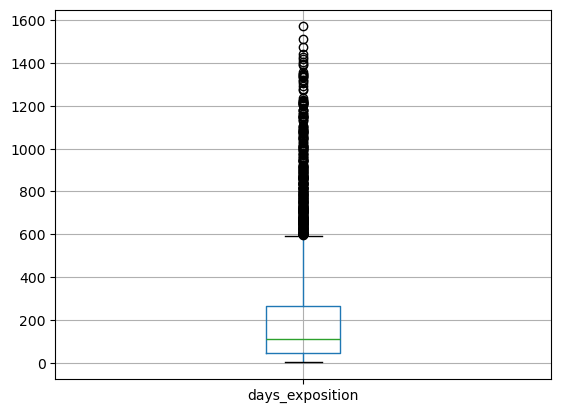

In [53]:
df.boxplot(column=['days_exposition'])
df['days_exposition'].describe()

Исходя из значений квартилей можно сказать, что квартиры которые проданых в диапазоне от 56 до 224 дней являются нормальными продажами. Если квартиры была продана меньше чем за 56 дней, то это быстрая продажа, а если больше чем за 224 дня - долгая

Чтобы определить есть ли завимисость между ценой и различными посмотрим на их коэфициенты корреляции.

In [54]:
for column in ['total_area', 'living_area', 'kitchen_area', 'rooms',
               'day_of_the_week', 'month_exposition', 'year_exposition']:
    print(f'Correlation between "last_price" and "{column}" is {df["last_price"].corr(df[column])}')

Correlation between "last_price" and "total_area" is 0.5920790302217763
Correlation between "last_price" and "living_area" is 0.5095878091714837
Correlation between "last_price" and "kitchen_area" is 0.5336762774806845
Correlation between "last_price" and "rooms" is 0.34559093558979853
Correlation between "last_price" and "day_of_the_week" is 0.015593934297074754
Correlation between "last_price" and "month_exposition" is -0.00510566945440283
Correlation between "last_price" and "year_exposition" is -0.06470445125433007


Видно, что есть небольшая зависимость связанная с размером кухни и кол-вом комнат и чуть большая зависимость связанная с жилой площадью и общей площадью. С датами же цена особо не связана

Чтобы выяснить от чего зависит цена проанализируем следующие столбцы и построим матрицу диаграм рассеяния:
- общая площадь;
- жилая площадь;
- площадь кухни;
- количество комнат;
- тип этажа, на котором расположена квартира (первый, последний, другой);
- дата размещения

array([[<Axes: xlabel='total_area', ylabel='total_area'>,
        <Axes: xlabel='living_area', ylabel='total_area'>,
        <Axes: xlabel='kitchen_area', ylabel='total_area'>,
        <Axes: xlabel='rooms', ylabel='total_area'>,
        <Axes: xlabel='floor_type_numeric', ylabel='total_area'>,
        <Axes: xlabel='last_price', ylabel='total_area'>,
        <Axes: xlabel='days_exposition', ylabel='total_area'>,
        <Axes: xlabel='day_of_the_week', ylabel='total_area'>,
        <Axes: xlabel='month_exposition', ylabel='total_area'>,
        <Axes: xlabel='year_exposition', ylabel='total_area'>],
       [<Axes: xlabel='total_area', ylabel='living_area'>,
        <Axes: xlabel='living_area', ylabel='living_area'>,
        <Axes: xlabel='kitchen_area', ylabel='living_area'>,
        <Axes: xlabel='rooms', ylabel='living_area'>,
        <Axes: xlabel='floor_type_numeric', ylabel='living_area'>,
        <Axes: xlabel='last_price', ylabel='living_area'>,
        <Axes: xlabel='days_expo

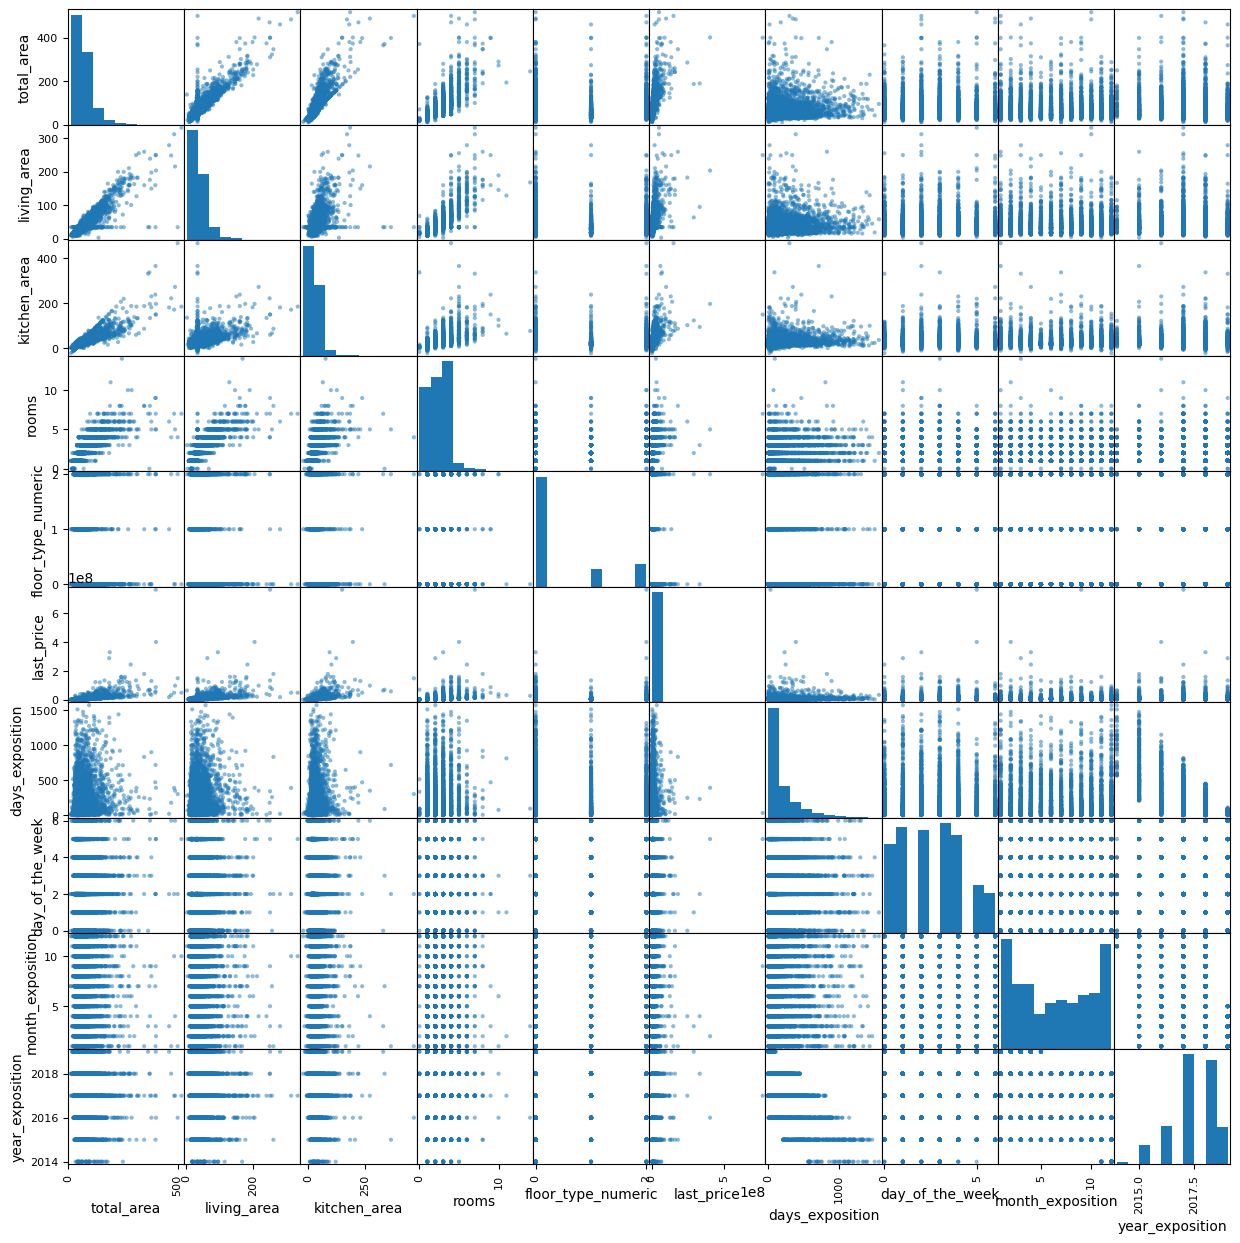

In [55]:
df['floor_type_numeric'] = df['floor_type'].astype('category').cat.codes

relevant_columns = df[['total_area', 'living_area', 'kitchen_area', 'rooms', 'floor_type_numeric', 'last_price', 'days_exposition', 'day_of_the_week', 'month_exposition', 'year_exposition']]

pd.plotting.scatter_matrix(relevant_columns, figsize=(15, 15))

Можно увидеть, что общая площадь, площадь кухни и жилая площадь влияют на цену недвижимости. Зависимость тут прямая - большая площадь как правило ведет к более высокой цене. То же самое касается и количества комнат. Квартиры расположенные на первом этаже как правило имеют более низкую цену, а относительно недавно размещенные как правило имеют чуть более высокую цену. День недели и месяц не особо влияют на цену, а вот более поздние года имеют немного выросшие цены на недвижимость.

In [56]:
pivot = df.pivot_table(index = 'locality_name', values = 'price_per_sqm', aggfunc = ['count', 'mean'])
pivot.columns = ['count', 'price_per_sqm']
(
    pivot.sort_values(by = 'count', ascending = False).head(10)
    .sort_values(by='price_per_sqm', ascending = False)
)

,count,price_per_sqm
locality_name,,
Санкт-Петербург,4228,128739.720220
Зеленогорск,16,109891.073125
Сестрорецк,72,108831.614583
Пушкин,133,107265.692782
Павловск,24,90949.239583
посёлок Стрельна,17,88558.942353
Петергоф,111,86604.563063
Кронштадт,81,79568.634938
Колпино,68,77017.248235


Как можно увидеть, самая большая цена в Санкт-Петербурге, а меньшая в Ломоносове. Скорее всего цены в Ломоносове можно объяснить удаленностью от большинства ценоопределяющих локаций

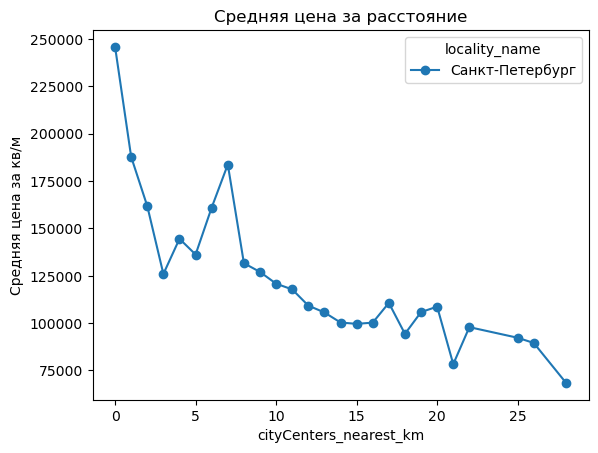

In [57]:
pivot_table = (
    df[df['locality_name'] == 'Санкт-Петербург']
    .pivot_table(index='locality_name', values='price_per_sqm', columns='cityCenters_nearest_km', aggfunc='mean')
)
sorted_pivot_table = pivot_table.sort_values(by=pivot_table.columns[0], ascending=False)
sorted_pivot_table.T.plot(kind='line', marker='o')
plt.ylabel('Средняя цена за кв/м')
plt.title('Средняя цена за расстояние')
plt.show()

Как видно удалённость от центра так же влияет на цену за недвижимость. Чем дальше от центра, тем дешевле

Проведя подробный анализ можно сказать, что на цену квартиры влияют несколько факторов. Больше всего влияет общая и жилая площади квартиры, чуть меньше площадь кухни и количество комнат. День недели, месяц особо не играют роли, но недавно размещенные квартиры, а так же более поздние года размещения имеют тенденцию иметь чуть более высокие цены. Квартиры расположенные на первом этаже продаются дешевле чем квартиры на других этажах. Расстояние до Аэропорта и Центра так же важно. Чем ближе, тем дороже. То же самое касается и насённого пункта, его близость к ключевым ценоопределяющим точка важна. Сам Санкт-Петербург имеет наибольшие цены за недвижимость тогда как Ломоносов - наименьшее. Санкт-Петербург так же лидирует по количеству объявлений, а Ломоносов имеет их меньше всего.